In [1]:
import os
import glob

import json
import numpy as np
import pandas as pd

from scipy.spatial.distance import cdist

import matplotlib.pyplot as plt
import matplotlib.patches as patches
import ipywidgets

In [2]:
DATA_DIR = "/mnt/nas/baecm/starcraft-vision/data"
INPUT_DIR = os.path.join(DATA_DIR, "input", "dst")
LABEL_DIR = os.path.join(DATA_DIR, "label", "dst")
MODEL_DIR = "/mnt/nas/baecm/starcraft-vision/models"
PREDICTION_DIR = "/mnt/nas/baecm/starcraft-vision/models/predictions"
RESULT_DIR = "./results"

In [3]:
import ipywidgets as widgets
from IPython.display import display, clear_output
import glob
import os
import json
import pandas as pd
import re # 숫자 정렬을 위해 추가
import numpy as np # npz 로드를 위해 추가 (필요시 사용)

# ---------------------------------------------------------
# 0. 변수 초기화 및 경로 설정
# ---------------------------------------------------------
# (INPUT_DIR, PREDICTION_DIR, LABEL_DIR 등은 사전에 정의되어 있다고 가정)

df_vanilla = None
df_kbrs = None
df_label = None 
input_npy_files = [] # 💡 Input 프레임 파일들의 경로를 담을 리스트
kbrs_cache_files = [] # 💡 추가: KBRS Cache(.npz) 파일들의 경로를 담을 리스트

# 폴드별 리플레이 목록 매핑 딕셔너리
FOLD_REPLAYS = {
    "fold1": ["1725.rep", "275.rep", "3613.rep", "4520.rep", "4664.rep"],
    "fold2": ["11251.rep", "1559.rep", "1628.rep", "2351.rep", "6219.rep"],
    "fold3": ["1660.rep", "212.rep", "36.rep", "438.rep", "522.rep"]
}

# ---------------------------------------------------------
# 1. 위젯(UI) 요소 생성
# ---------------------------------------------------------
fold_dropdown = widgets.Dropdown(
    options=["fold1", "fold2", "fold3"],
    value="fold1",
    description="Fold:"
)

replay_dropdown = widgets.Dropdown(
    options=FOLD_REPLAYS["fold1"],
    value=FOLD_REPLAYS["fold1"][0],
    description="Replay:"
)

seed_dropdown = widgets.Dropdown(
    options=[("123", "s123"), ("456", "s456"), ("789", "s789")],
    value="s123",
    description="Seed:"
)

load_button = widgets.Button(description="데이터 로드 🚀", button_style='info')
out = widgets.Output()

def on_fold_change(change):
    selected_fold = change['new']
    replay_dropdown.options = FOLD_REPLAYS[selected_fold]
    replay_dropdown.value = FOLD_REPLAYS[selected_fold][0] 

fold_dropdown.observe(on_fold_change, names='value')

# 💡 파일명에서 숫자를 추출하여 정렬하기 위한 헬퍼 함수
# (1.npy, 2.npy, 10.npy 순서로 제대로 정렬되게 함)
def natural_sort_key(s):
    return [int(text) if text.isdigit() else text.lower() for text in re.split(r'(\d+)', s)]

# ---------------------------------------------------------
# 2. 버튼 클릭 시 실행될 동작(Callback 함수) 정의
# ---------------------------------------------------------
def on_button_clicked(b):
    global df_vanilla, df_kbrs, df_label, input_npy_files, kbrs_cache_files 
    
    with out:
        clear_output(wait=True) 
        
        fold_choice = fold_dropdown.value
        seed_choice = seed_dropdown.value
        replay_choice = replay_dropdown.value
        
        print(f"선택된 조건 - Fold: {fold_choice} / Seed: {seed_choice} / Replay: {replay_choice}")
        print("-" * 50)
        
        try:
            # ========================================================
            # 1. Input(.npy) 경로 탐색 및 리스트 스캔
            # ========================================================
            current_input_dir = os.path.join(INPUT_DIR, replay_choice)
            if os.path.exists(current_input_dir):
                npy_list = glob.glob(os.path.join(current_input_dir, "*.npy"))
                input_npy_files = sorted(npy_list, key=natural_sort_key)
                print(f"🖼️ Input 프레임(.npy) ({len(input_npy_files)}개) 스캔 완료")
            else:
                input_npy_files = []
                print(f"⚠️ 경고: Input 디렉토리를 찾을 수 없습니다. ({current_input_dir})")

            # ========================================================
            # 2. (추가됨) KBRS Cache(.npz) 경로 탐색 및 리스트 스캔
            # ========================================================
            cache_pattern = os.path.join(INPUT_DIR, "__kbrs_cache__", "norm01", replay_choice, "*.npz")
            npz_list = glob.glob(cache_pattern)
            
            if npz_list:
                # npz 파일들도 숫자기준 오름차순으로 정렬
                kbrs_cache_files = sorted(npz_list, key=natural_sort_key)
                print(f"📦 KBRS Cache(.npz) ({len(kbrs_cache_files)}개) 스캔 완료")
            else:
                kbrs_cache_files = []
                print(f"⚠️ 경고: KBRS Cache 디렉토리에서 .npz 파일을 찾을 수 없습니다. ({cache_pattern})")

            # ========================================================
            # 3. Prediction 및 Label 로드
            # ========================================================
            VANILLA_DIRS = glob.glob(os.path.join(PREDICTION_DIR, f"all_correct*vanilla*{fold_choice}*{seed_choice}*"))
            KBRS_DIRS = glob.glob(os.path.join(PREDICTION_DIR, f"all_correct*{fold_choice}*{seed_choice}*kbrs025*base_score*"))
            
            if VANILLA_DIRS and KBRS_DIRS:
                print("-" * 50)
                
                vanilla_json_file = os.path.join(VANILLA_DIRS[0], "model_030", replay_choice, "all_correct.json")
                kbrs_json_file = os.path.join(KBRS_DIRS[0], "model_030", replay_choice, "all_correct.json")
                label_json_file = os.path.join(LABEL_DIR, replay_choice, "all_correct.json")

                if os.path.exists(label_json_file):
                    with open(label_json_file, "r") as f:
                        label_json_data = json.load(f)
                    df_label = pd.DataFrame(label_json_data["annotations"])
                    print(f"🎯 정답(Label) 로드 성공 : {replay_choice}/all_correct.json")
                else:
                    print(f"⚠️ 경고: 정답 파일을 찾을 수 없습니다. ({label_json_file})")
                    df_label = None

                if os.path.exists(vanilla_json_file) and os.path.exists(kbrs_json_file):
                    with open(vanilla_json_file, "r") as f:
                        vanilla_json_data = json.load(f)
                    with open(kbrs_json_file, "r") as f:
                        kbrs_json_data = json.load(f)

                    df_vanilla = pd.DataFrame(vanilla_json_data["annotations"])
                    df_kbrs = pd.DataFrame(kbrs_json_data["annotations"])
                    
                    print(f"✅ 예측(Pred) 로드 성공  : Vanilla, KBRS ({replay_choice})")
                    print("-" * 50)
                    print("🚀 모든 데이터 경로 및 파일 로드 완료!")
                    print("   사용 가능 변수: input_npy_files, kbrs_cache_files, df_vanilla, df_kbrs, df_label")
                else:
                    print(f"❌ 선택한 리플레이({replay_choice})의 예측 결과 파일(all_correct.json)이 존재하지 않습니다.")

            else:
                print("❌ 조건에 맞는 Prediction 최상위 디렉토리를 찾을 수 없습니다.")
                
        except Exception as e:
            print(f"❌ 에러 발생: {e}")

# ---------------------------------------------------------
# 4. 버튼에 함수 연결 및 화면 출력
# ---------------------------------------------------------
load_button.on_click(on_button_clicked)

ui = widgets.HBox([fold_dropdown, replay_dropdown, seed_dropdown, load_button])
display(ui, out)

Output()

In [67]:
# --- 상수로 박스 크기 고정 ---
BOX_W = 20
BOX_H = 12
BOX_AREA = BOX_W * BOX_H # 240

In [66]:
def calculate_fixed_iou_matrix(coords1, coords2):
    """ 너비 20, 높이 12로 고정된 두 [x, y] 좌표 그룹 간의 초고속 IoU 행렬 계산 """
    if len(coords1) == 0 or len(coords2) == 0:
        return np.zeros((len(coords1), len(coords2)))

    # x, y 분리 (N, 1) & (1, M) 형태로 브로드캐스팅
    c1_x, c1_y = coords1[:, 0], coords1[:, 1]
    c2_x, c2_y = coords2[:, 0], coords2[:, 1]

    # 교집합(Intersection) 영역의 좌상단 및 우하단 좌표 계산
    inter_x1 = np.maximum(c1_x[:, None], c2_x)
    inter_y1 = np.maximum(c1_y[:, None], c2_y)
    inter_x2 = np.minimum(c1_x[:, None] + BOX_W, c2_x + BOX_W)
    inter_y2 = np.minimum(c1_y[:, None] + BOX_H, c2_y + BOX_H)

    # 겹치는 너비와 높이 (안 겹치면 0)
    inter_w = np.clip(inter_x2 - inter_x1, 0, None)
    inter_h = np.clip(inter_y2 - inter_y1, 0, None)
    
    # 교집합 면적
    inter_area = inter_w * inter_h
    
    # 합집합 면적 (240 + 240 - 교집합)
    union_area = (2 * BOX_AREA) - inter_area
    
    return inter_area / np.maximum(union_area, 1e-6)

In [68]:
def track_streaks_iou_fixed(df, iou_threshold=0.3):
    # bbox에서 좌상단 x, y만 빠르게 추출 (w, h 무시)
    df['x'] = df['bbox'].apply(lambda b: b[0])
    df['y'] = df['bbox'].apply(lambda b: b[1])
    
    image_ids = sorted(df['image_id'].unique())
    
    # 변수 초기화
    df['streak_id'] = -1
    df['dx'], df['dy'], df['iou_score'], df['angle'] = np.nan, np.nan, np.nan, np.nan
    next_streak_id = 0
    
    # 첫 프레임 초기화
    first_frame_idx = df[df['image_id'] == image_ids[0]].index
    for idx in first_frame_idx:
        df.at[idx, 'streak_id'] = next_streak_id
        next_streak_id += 1
        
    for i in range(len(image_ids) - 1):
        curr_id, next_id = image_ids[i], image_ids[i+1]
        
        curr_rows = df[df['image_id'] == curr_id]
        next_rows = df[df['image_id'] == next_id]
        
        if curr_rows.empty or next_rows.empty: continue
            
        # 순수 x, y 좌표값만 넘김
        curr_coords = curr_rows[['x', 'y']].values
        next_coords = next_rows[['x', 'y']].values
        
        # 고정 사이즈 IoU 계산
        iou_matrix = calculate_fixed_iou_matrix(curr_coords, next_coords)
        
        matched_next_indices = set() # 검색 속도 향상을 위해 list 대신 set 사용
        
        for curr_idx_in_matrix in range(len(curr_rows)):
            max_iou = iou_matrix[curr_idx_in_matrix].max()
            next_idx_in_matrix = iou_matrix[curr_idx_in_matrix].argmax()
            
            if max_iou > iou_threshold and next_idx_in_matrix not in matched_next_indices:
                actual_next_idx = next_rows.index[next_idx_in_matrix]
                actual_curr_idx = curr_rows.index[curr_idx_in_matrix]
                
                # ID 계승
                df.at[actual_next_idx, 'streak_id'] = df.at[actual_curr_idx, 'streak_id']
                
                # 크기가 같으므로 중심점을 구하지 않아도 (next_x - curr_x)가 곧 중심점 간의 거리(dx)와 같습니다.
                dx = next_coords[next_idx_in_matrix][0] - curr_coords[curr_idx_in_matrix][0]
                dy = next_coords[next_idx_in_matrix][1] - curr_coords[curr_idx_in_matrix][1]
                
                df.at[actual_next_idx, 'dx'] = dx
                df.at[actual_next_idx, 'dy'] = dy
                df.at[actual_next_idx, 'iou_score'] = max_iou
                df.at[actual_next_idx, 'angle'] = np.degrees(np.arctan2(dy, dx))
                
                matched_next_indices.add(next_idx_in_matrix)
        
        # 매칭 실패한 객체에 새 ID 부여
        for j, next_idx in enumerate(next_rows.index):
            if j not in matched_next_indices:
                df.at[next_idx, 'streak_id'] = next_streak_id
                next_streak_id += 1
                
    return df

In [9]:
# 실행
df_vanilla_tracked = track_streaks_iou_fixed(df_vanilla, iou_threshold=0.75)

# Streak 길이(지속성) 측정
streak_lengths = df_vanilla_tracked.groupby('streak_id').size()
print(streak_lengths)

streak_id
0        2742
1          36
2           2
3         170
4         119
         ... 
14261       1
14262       1
14263      16
14264      14
14265       1
Length: 14266, dtype: int64


In [69]:
df_vanilla_tracked

,id,image_id,category_id,bbox,score,area,segmentation,iscrowd,x,y,streak_id,dx,dy,iou_score,angle
0,1,3,1,"[0, 0, 19, 12]",0.796460,228,"[[0, 0, 19, 0, 19, 12, 0, 12]]",0,0,0,0,NaN,NaN,NaN,NaN
1,2,3,1,"[108, 114, 19, 12]",0.732251,228,"[[108, 114, 127, 114, 127, 126, 108, 126]]",0,108,114,1,NaN,NaN,NaN,NaN
2,3,4,1,"[0, 0, 19, 12]",0.796460,228,"[[0, 0, 19, 0, 19, 12, 0, 12]]",0,0,0,0,0.0,0.0,1.0,0.0
3,4,4,1,"[108, 114, 19, 12]",0.732251,228,"[[108, 114, 127, 114, 127, 126, 108, 126]]",0,108,114,1,0.0,0.0,1.0,0.0
4,5,5,1,"[0, 0, 19, 12]",0.796460,228,"[[0, 0, 19, 0, 19, 12, 0, 12]]",0,0,0,0,0.0,0.0,1.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
108818,108819,18187,1,"[97, 85, 20, 12]",0.999327,240,"[[97, 85, 117, 85, 117, 97, 97, 97]]",0,97,85,14263,0.0,0.0,1.0,0.0
108819,108820,18187,1,"[91, 84, 20, 12]",0.995479,240,"[[91, 84, 111, 84, 111, 96, 91, 96]]",0,91,84,14260,0.0,0.0,1.0,0.0
108820,108821,18187,1,"[4, 108, 20, 12]",0.816467,240,"[[4, 108, 24, 108, 24, 120, 4, 120]]",0,4,108,13125,0.0,0.0,1.0,0.0
108821,108822,18187,1,"[66, 111, 20, 12]",0.799796,240,"[[66, 111, 86, 111, 86, 123, 66, 123]]",0,66,111,14246,0.0,0.0,1.0,0.0


In [10]:
# 실행
df_kbrs_tracked = track_streaks_iou_fixed(df_kbrs, iou_threshold=0.75)

# Streak 길이(지속성) 측정
streak_lengths = df_kbrs_tracked.groupby('streak_id').size()
print(streak_lengths)

streak_id
0         934
1        3278
2          16
3           2
4          15
         ... 
13188       2
13189       2
13190       1
13191       4
13192       3
Length: 13193, dtype: int64


In [11]:
df_label_tracked = track_streaks_iou_fixed(df_label, iou_threshold=0.75)

# Streak 길이(지속성) 측정
streak_lengths = df_label_tracked.groupby('streak_id').size()
print(streak_lengths)

streak_id
0        92
1         1
2         1
3         1
4         1
       ... 
7346      1
7347      1
7348      1
7349    103
7350     35
Length: 7351, dtype: int64


In [42]:
# %matplotlib inline

# import matplotlib.pyplot as plt
# import matplotlib.patches as patches
# import ast
# import ipywidgets as widgets
# from IPython.display import display
# import numpy as np 
# import os

# def interactive_rank_viewer(vanilla=None, kbrs=None, gt=None, input_files=None, kbrs_cache_files=None, grid_size=128):
    
#     frames_vanilla = set(vanilla['image_id'].dropna().unique()) if vanilla is not None else set()
#     frames_kbrs = set(kbrs['image_id'].dropna().unique()) if kbrs is not None else set()
#     frames_gt = set(gt['image_id'].dropna().unique()) if gt is not None else set()
    
#     frames_input = set()
#     if input_files:
#         for f in input_files:
#             try:
#                 fname = os.path.basename(f)
#                 frame_id_str = os.path.splitext(fname)[0]
#                 frames_input.add(int(frame_id_str))
#             except ValueError:
#                 pass 
                
#     frame_list = sorted(list(frames_vanilla | frames_kbrs | frames_gt | frames_input))
    
#     if not frame_list:
#         print("데이터프레임이나 입력 파일에 유효한 프레임이 없습니다.")
#         return

#     def draw_plot(frame_id, top_n, show_terrain, show_resources, show_vision, show_units, show_density, show_centeredness, show_mixture):
#         fig, ax = plt.subplots(figsize=(16, 9)) 
        
#         # -----------------------------------------------------
#         # 0. KBRS Cache(.npz) 파일 미리 로드
#         # -----------------------------------------------------
#         cache_data = None
#         npz_file_path = None
#         if kbrs_cache_files:
#             expected_npz_name = f"{frame_id}.npz"
#             for f in kbrs_cache_files:
#                 if os.path.basename(f) == expected_npz_name:
#                     npz_file_path = f
#                     break

#         if npz_file_path and os.path.exists(npz_file_path):
#             try:
#                 cache_data = np.load(npz_file_path)
#             except Exception as e:
#                 print(f"npz 파일 로드 에러 ({npz_file_path}): {e}")
        
#         # -----------------------------------------------------
#         # 1. 맵 데이터(.npy) 로드 및 시각화
#         # -----------------------------------------------------
#         input_file_path = None
#         if input_files:
#             expected_name = f"{frame_id}.npy"
#             for f in input_files:
#                 if os.path.basename(f) == expected_name:
#                     input_file_path = f
#                     break
        
#         if input_file_path and os.path.exists(input_file_path):
#             try:
#                 map_data = np.load(input_file_path)
                
#                 if map_data.ndim == 3 and map_data.shape[0] >= 11:
#                     h, w = map_data.shape[1], map_data.shape[2]
#                     rgb_img = np.zeros((h, w, 3), dtype=np.float32)
#                     boost_factor = 3.0 
                    
#                     p1_units = np.clip(np.max(map_data[0:4, :, :], axis=0) * boost_factor, 0, 1) if show_units else np.zeros((h, w))
#                     p2_units = np.clip(np.max(map_data[4:8, :, :], axis=0) * boost_factor, 0, 1) if show_units else np.zeros((h, w))
#                     resources = map_data[8, :, :] if show_resources else np.zeros((h, w))
#                     vision = map_data[9, :, :]
#                     terrain_gray = (map_data[10, :, :] * 0.4) if show_terrain else np.zeros((h, w))
                    
#                     rgb_img[:, :, 0] = np.maximum(terrain_gray, p1_units)
#                     rgb_img[:, :, 1] = np.maximum(terrain_gray, resources)
#                     rgb_img[:, :, 2] = np.maximum(np.maximum(terrain_gray, resources), p2_units)
                    
#                     if show_vision:
#                         fog_mask = np.where(vision > 0, 1.0, 0.25)
#                         rgb_img = rgb_img * fog_mask[:, :, np.newaxis]
                    
#                     rgb_img = np.clip(rgb_img, 0, 1)
#                     ax.imshow(rgb_img, extent=[0, grid_size, grid_size, 0], alpha=1.0, zorder=1)
                    
#                 else:
#                     flat_map = np.squeeze(map_data)
#                     if flat_map.ndim > 2: flat_map = flat_map[0]
#                     ax.imshow(flat_map, cmap='gray', extent=[0, grid_size, grid_size, 0], alpha=1.0, zorder=1)
                
#             except Exception as e:
#                 print(f"npy 파일 로드 에러 ({input_file_path}): {e}")

#         # -----------------------------------------------------
#         # 2. KBRS Cache(.npz) 히트맵 시각화
#         # -----------------------------------------------------
#         if cache_data is not None:
#             try:
#                 cache_h, cache_w = cache_data['density'].shape
#                 heatmap = None
#                 if show_density:
#                     heatmap = cache_data['density']
#                 if show_centeredness:
#                     heatmap = cache_data['centeredness'] if heatmap is None else heatmap * cache_data['centeredness']
#                 if show_mixture:
#                     heatmap = cache_data['mixture'] if heatmap is None else heatmap * cache_data['mixture']
                
#                 if heatmap is not None:
#                     ax.imshow(heatmap, cmap='magma', alpha=0.5, extent=[0, cache_w, cache_h, 0], zorder=2)
#             except Exception as e:
#                 print(f"npz 히트맵 시각화 에러: {e}")

#         # -----------------------------------------------------
#         # 3. 데이터 수집 및 사이드 패널 정렬 배치 로직
#         # -----------------------------------------------------
#         datasets = [
#             (vanilla, "Vanilla"),
#             (kbrs, "KBRS"),
#             (gt, "GT")
#         ]
        
#         collected_boxes = []

#         for df, prefix in datasets:
#             if df is None: continue
#             now_df = df[df['image_id'] == frame_id].copy()
#             if now_df.empty: continue

#             has_score = 'score' in now_df.columns
#             if has_score:
#                 if 'rank' not in now_df.columns:
#                     now_df['rank'] = now_df['score'].rank(ascending=False, method='first').astype(int)
#                 now_df = now_df[now_df['rank'] <= top_n]

#             for _, row in now_df.iterrows():
#                 bbox = row['bbox']
#                 if isinstance(bbox, str): bbox = ast.literal_eval(bbox)
                
#                 rank = int(row['rank']) if has_score else None
#                 score = row['score'] if has_score else None
                
#                 cache_text = ""
#                 if cache_data is not None:
#                     try:
#                         cache_h, cache_w = cache_data['density'].shape
#                         cx = int(np.clip(bbox[0] + 10, 0, cache_w - 1))
#                         cy = int(np.clip(bbox[1] + 6, 0, cache_h - 1))
                        
#                         # 1. 존재하는 3개 항목만 캐시 파일에서 읽어옴
#                         d_val = cache_data['density'][cy, cx]
#                         c_val = cache_data['centeredness'][cy, cx]
#                         m_val = cache_data['mixture'][cy, cx]
                        
#                         # 2. 💡 Score를 동적으로 계산 (합산 방식에 맞춰 수정 가능)
#                         # s_val = d_val * c_val * m_val  # 덧셈이 필요하면 d_val + c_val + m_val 로 변경
                        
#                         # 3. 고정 자릿수 포맷팅 적용
#                         # cache_text = f" [D:{d_val:4.2f} C:{c_val:4.2f} M:{m_val:4.2f} S:{s_val:4.2f}]"
#                         cache_text = f" [D:{d_val:4.2f} C:{c_val:4.2f} M:{m_val:4.2f}]"
#                     except Exception as e:
#                         # 디버깅을 위해 에러 메시지 출력(필요시 생략 가능)
#                         # print(f"Cache data extraction error: {e}")
#                         pass
                
#                 collected_boxes.append({
#                     'prefix': prefix,
#                     'bbox': bbox,
#                     'rank': rank,
#                     'score': score,
#                     'cache_text': cache_text
#                 })

#         prefix_order = {"GT": 0, "Vanilla": 1, "KBRS": 2}
#         collected_boxes.sort(key=lambda x: (prefix_order.get(x['prefix'], 3), x['rank'] if x['rank'] is not None else 0))

#         # 💡 [문자열 다중 열(Column) 정렬 배치 버전]
#         current_y = 6   
#         y_step = 6     

#         for item in collected_boxes:
#             prefix = item['prefix']
#             bbox = item['bbox']
#             rank = item['rank']
#             score = item['score']
#             cache_text = item['cache_text']
            
#             # 스타일 지정 (기존과 동일)
#             if prefix == "Vanilla":
#                 face_color = "none"; edge_color = "blue"; text_bg = "blue"; text_color = "white"; line_style = "--"
#             elif prefix == "KBRS":
#                 face_color = "none"; edge_color = "red"; text_bg = "red"; text_color = "yellow"; line_style = "--"
#             else: # GT
#                 face_color = "none"; edge_color = "green"; text_bg = "lightgreen"; text_color = "black"; line_style = "-"

#             # 1. 미니맵 내부에 바운딩 박스 렌더링
#             rect = patches.Rectangle(
#                 (bbox[0], bbox[1]), 20, 12,
#                 edgecolor=edge_color, facecolor=face_color,
#                 linestyle=line_style, linewidth=1.5, zorder=3
#             )
#             ax.add_patch(rect)

#             # 2. 💡 [핵심 수정] 각 항목별 고정 자릿수(패딩) 처리로 완벽한 열 맞춤
#             # 1) 데이터셋 태그 필드 고정 (가장 긴 [Vanilla]가 9자이므로 11칸 확보)
#             dataset_field = f"[{prefix}]"
#             dataset_field = f"{dataset_field:<11}"
            
#             # 2) 랭크 및 스코어 필드 고정 (가장 긴 'R:10 (0.000)' 형태 고려하여 14칸 확보, GT는 공백으로 채워짐)
#             if rank is not None:
#                 rank_field = f"R:{rank} ({score:.3f})"
#             else:
#                 rank_field = ""  # 💡 GT는 빈 문자열로 두어 공백이 채워지게 만듦
#             rank_field = f"{rank_field:<14}"
            
#             # 3) 세 필드를 순서대로 결합하여 최종 텍스트 생성
#             label_text = f"{dataset_field}{rank_field}{cache_text}"

#             # 3. 화살표 어노테이션 연결 (고정폭 폰트 및 정좌측 꼬리 고정 유지)
#             ax.annotate(
#                 label_text,
#                 xy=(bbox[0] + 20, bbox[1] + 6),
#                 xytext=(137, current_y),
#                 color=text_color, 
#                 fontsize=8, fontweight='bold',
#                 family='monospace',  # 💡 고정폭 폰트 필수
#                 ha='left',        
#                 va='center',      
#                 bbox=dict(facecolor=text_bg, alpha=0.75, edgecolor='none', pad=2),
#                 arrowprops=dict(
#                     arrowstyle="->",
#                     color=edge_color,
#                     lw=1.0,
#                     alpha=0.6,
#                     connectionstyle="arc3,rad=-0.1",
#                     relpos=(0, 0.5)  # 💡 왼쪽 정중앙에서 화살표 출발 고정
#                 ),
#                 zorder=5
#             )
            
#             current_y += y_step

#         # -----------------------------------------------------
#         # 4. 축 범위 및 뷰 고정
#         # -----------------------------------------------------
#         ax.set_xlim(-5, 215)
#         ax.set_ylim(max(grid_size + 10, current_y + 10), -5) 
#         ax.set_aspect('equal') 
#         ax.set_xticks([])
#         ax.set_yticks([])
#         ax.axvline(x=135, color='gray', linestyle=':', alpha=0.5)

#         plt.title(f"Comparing Predictions vs GT - Frame: {frame_id}")
#         plt.show()

#     # -----------------------------------------------------
#     # 5. 💡 위젯 UI 구성 (한 프레임 앞/뒤 제어 버튼 추가됨)
#     # -----------------------------------------------------
#     frame_slider = widgets.SelectionSlider(
#         options=frame_list, value=frame_list[0], description='Frame ID:',
#         disabled=False, continuous_update=False, orientation='horizontal',
#         readout=True, layout=widgets.Layout(width='400px') # 버튼 공간 확보를 위해 너비 소폭 조정
#     )
    
#     # 💡 이전/다음 이동용 버튼 생성
#     btn_prev = widgets.Button(description="◀ 이전", layout=widgets.Layout(width='70px'), button_style='')
#     btn_next = widgets.Button(description="다음 ▶", layout=widgets.Layout(width='70px'), button_style='')
    
#     # 💡 버튼 클릭 시 실행될 경계면 탐색 및 슬라이더 값 제어 함수
#     def move_frame_step(step):
#         try:
#             curr_idx = frame_list.index(frame_slider.value)
#             new_idx = curr_idx + step
#             # 인덱스 범위를 벗어나지 않도록 제한(Clipping)
#             if 0 <= new_idx < len(frame_list):
#                 frame_slider.value = frame_list[new_idx]
#         except ValueError:
#             pass

#     # 이벤트 연결
#     btn_prev.on_click(lambda b: move_frame_step(-1))
#     btn_next.on_click(lambda b: move_frame_step(1))

#     top_n_slider = widgets.IntSlider(value=3, min=1, max=20, step=1, description='Top N:')

#     # 💡 레이아웃 구성: [이전] [슬라이더] [다음] 순서로 가로 배치
#     ui_frame_controls = widgets.HBox([btn_prev, frame_slider, btn_next, top_n_slider])

#     cb_terrain = widgets.Checkbox(value=True, description='Terrain', indent=False, layout=widgets.Layout(width='100px'))
#     cb_resources = widgets.Checkbox(value=True, description='Resources', indent=False, layout=widgets.Layout(width='100px'))
#     cb_vision = widgets.Checkbox(value=True, description='Fog of War', indent=False, layout=widgets.Layout(width='100px'))
#     cb_units = widgets.Checkbox(value=True, description='Units', indent=False, layout=widgets.Layout(width='100px'))
#     ui_map_checkboxes = widgets.HBox([cb_terrain, cb_resources, cb_vision, cb_units])

#     cb_density = widgets.Checkbox(value=False, description='Density', indent=False, layout=widgets.Layout(width='100px'))
#     cb_centeredness = widgets.Checkbox(value=False, description='Centeredness', indent=False, layout=widgets.Layout(width='100px'))
#     cb_mixture = widgets.Checkbox(value=False, description='Mixture', indent=False, layout=widgets.Layout(width='100px'))
#     ui_npz_checkboxes = widgets.HBox([widgets.Label("Kernel Scores:"), cb_density, cb_centeredness, cb_mixture])

#     out = widgets.interactive_output(draw_plot, {
#         'frame_id': frame_slider, 'top_n': top_n_slider,
#         'show_terrain': cb_terrain, 'show_resources': cb_resources, 'show_vision': cb_vision, 'show_units': cb_units,
#         'show_density': cb_density, 'show_centeredness': cb_centeredness, 'show_mixture': cb_mixture
#     })

#     # 전체 UI 출력
#     display(widgets.VBox([ui_frame_controls, ui_map_checkboxes, ui_npz_checkboxes, out]))

In [41]:
# # 실행부
# interactive_rank_viewer(
#     vanilla=df_vanilla, kbrs=df_kbrs, gt=df_label, 
#     input_files=input_npy_files, kbrs_cache_files=kbrs_cache_files
# )

In [43]:
def calculate_fixed_iou_matrix(coords1, coords2):
    if len(coords1) == 0 or len(coords2) == 0:
        return np.zeros((len(coords1), len(coords2)))
    c1_x, c1_y = coords1[:, 0], coords1[:, 1]
    c2_x, c2_y = coords2[:, 0], coords2[:, 1]
    inter_x1 = np.maximum(c1_x[:, None], c2_x)
    inter_y1 = np.maximum(c1_y[:, None], c2_y)
    inter_x2 = np.minimum(c1_x[:, None] + BOX_W, c2_x + BOX_W)
    inter_y2 = np.minimum(c1_y[:, None] + BOX_H, c2_y + BOX_H)
    inter_w = np.clip(inter_x2 - inter_x1, 0, None)
    inter_h = np.clip(inter_y2 - inter_y1, 0, None)
    inter_area = inter_w * inter_h
    union_area = (2 * (BOX_W * BOX_H)) - inter_area
    return inter_area / np.maximum(union_area, 1e-6)

In [44]:
def get_cache_text(bbox, cache_data):
    if cache_data is None: return ""
    try:
        cache_h, cache_w = cache_data['density'].shape
        cx = int(np.clip(bbox[0] + 10, 0, cache_w - 1))
        cy = int(np.clip(bbox[1] + 6, 0, cache_h - 1))
        d = cache_data['density'][cy, cx]
        c = cache_data['centeredness'][cy, cx]
        m = cache_data['mixture'][cy, cx]
        s = d * c * m
        return f" [D:{d:4.2f} C:{c:4.2f} M:{m:4.2f} S:{s:4.2f}]"
    except: return ""

In [53]:
%matplotlib inline

import matplotlib.pyplot as plt
import matplotlib.patches as patches
import ast
import ipywidgets as widgets
from IPython.display import display, clear_output
import numpy as np 
import os

BOX_W = 20
BOX_H = 12

# ---------------------------------------------------------
# 메인 뷰어 함수
# ---------------------------------------------------------
def interactive_rank_viewer(vanilla=None, kbrs=None, gt=None, input_files=None, kbrs_cache_files=None, grid_size=128):
    frames_vanilla = set(vanilla['image_id'].dropna().unique()) if vanilla is not None else set()
    frames_kbrs = set(kbrs['image_id'].dropna().unique()) if kbrs is not None else set()
    frames_gt = set(gt['image_id'].dropna().unique()) if gt is not None else set()
    
    frames_input = set()
    if input_files:
        for f in input_files:
            try:
                frame_id_str = os.path.splitext(os.path.basename(f))[0]
                frames_input.add(int(frame_id_str))
            except: pass
                
    frame_list = sorted(list(frames_vanilla | frames_kbrs | frames_gt | frames_input))
    
    if not frame_list:
        print("데이터프레임이나 입력 파일에 유효한 프레임이 없습니다.")
        return

    def draw_plot(frame_id, top_n, show_terrain, show_resources, show_vision, show_units, show_density, show_centeredness, show_mixture):
        fig, ax = plt.subplots(figsize=(16, 9)) 
        
        # 0. Cache 로드
        cache_data = None
        if kbrs_cache_files:
            expected_npz_name = f"{frame_id}.npz"
            for f in kbrs_cache_files:
                if os.path.basename(f) == expected_npz_name:
                    try: cache_data = np.load(f)
                    except: pass
                    break
        
        # 1. 맵 시각화
        input_file_path = None
        if input_files:
            expected_name = f"{frame_id}.npy"
            for f in input_files:
                if os.path.basename(f) == expected_name:
                    input_file_path = f
                    break
        
        if input_file_path and os.path.exists(input_file_path):
            try:
                map_data = np.load(input_file_path)
                if map_data.ndim == 3 and map_data.shape[0] >= 11:
                    h, w = map_data.shape[1], map_data.shape[2]
                    
                    # 💡 초기 배경을 '완전 투명'으로 설정 (RGBA: 0,0,0,0)
                    rgba_img = np.zeros((h, w, 4), dtype=np.float32)
                    
                    # 레이어 병합용 임시 RGB 버퍼
                    layer_rgb = np.zeros((h, w, 3), dtype=np.float32)
                    
                    # 레이어별 합성 함수 (값 > 0 인 곳만 합성)
                    def apply_layer(data, color, intensity=1.0):
                        mask = data > 0
                        # 해당 채널의 값만큼 색상을 더하고, 알파 마스크를 갱신
                        for c in range(3):
                            if color[c] > 0:
                                layer_rgb[mask, c] = np.maximum(layer_rgb[mask, c], data[mask] * intensity)
                        rgba_img[mask, 3] = 1.0 # 정보가 있는 곳은 불투명 처리

                    # 1. Terrain (Gray) - 순서: 지형 -> 자원 -> 유닛 -> 시야
                    if show_terrain:
                        apply_layer(map_data[10, :, :] * 0.4, (1, 1, 1))
                    
                    # 2. Resources (Cyan)
                    if show_resources:
                        apply_layer(map_data[8, :, :], (0, 1, 1))
                        
                    # 3. Units (Red/Blue)
                    if show_units:
                        boost = 3.0
                        apply_layer(np.max(map_data[0:4, :, :], axis=0) * boost, (1, 0, 0)) # Red
                        apply_layer(np.max(map_data[4:8, :, :], axis=0) * boost, (0, 0, 1)) # Blue
                    
                    # 4. 최종 합성: RGB에 알파 채널 붙이기
                    rgba_img[:, :, 0:3] = layer_rgb
                    
                    # 4. Vision (Fog of War) - 시야가 없는 곳(0)을 어둡게 처리
                    if show_vision:
                        vis = map_data[9, :, :]
                        
                        # 💡 Vision이 0인 곳(Fog)은 알파를 0.25로, 1인 곳은 1.0으로 설정
                        fog_alpha = np.where(vis > 0, 1.0, 0.25)
                        
                        # 이미 채워진 rgb 영역에 fog_alpha를 곱하여 
                        # 안개 지역은 어둡게, 시야 확보 지역은 원래 색상 유지
                        rgba_img[:, :, 0:3] *= fog_alpha[:, :, np.newaxis]
                        
                        # 안개 지역도 정보가 있는 것으로 간주하여 알파 채널을 1.0으로 유지
                        # (안개도 맵의 일부이므로 투명하게 날리면 안 되기 때문)
                        rgba_img[:, :, 3] = 1.0
                    
                    ax.imshow(np.clip(rgba_img, 0, 1), extent=[0, grid_size, grid_size, 0], zorder=1)
            except: pass

        # 2. KBRS Cache(.npz) 히트맵 시각화
        if cache_data is not None:
            try:
                # 💡 데이터의 실제 크기를 그대로 사용
                h_map, w_map = cache_data['density'].shape
                
                heatmap = None
                if show_density:
                    heatmap = cache_data['density']
                if show_centeredness:
                    val = cache_data['centeredness']
                    heatmap = val if heatmap is None else heatmap * val
                if show_mixture:
                    val = cache_data['mixture']
                    heatmap = val if heatmap is None else heatmap * val
                
                if heatmap is not None:
                    # 💡 extent를 [0, w_map, h_map, 0]으로 설정하여
                    # 늘어나지 않게 하고, 맵의 좌상단(0,0)에 그대로 얹습니다.
                    # aspect='equal'을 기본으로 하여 왜곡을 방지합니다.
                    ax.imshow(heatmap, 
                              cmap='magma', 
                              alpha=0.5, 
                              extent=[0, w_map, h_map, 0], 
                              aspect='equal', 
                              origin='upper', 
                              zorder=2)
            except Exception as e:
                print(f"npz 히트맵 시각화 에러: {e}")

        # 3. 정답 및 예측 매칭
        gt_items = []
        if gt is not None:
            now_gt = gt[gt['image_id'] == frame_id]
            for i, (_, row) in enumerate(now_gt.iterrows()):
                b = ast.literal_eval(row['bbox']) if isinstance(row['bbox'], str) else row['bbox']
                gt_items.append({'prefix': 'GT', 'bbox': b, 'rank': None, 'score': None,
                                 'cache_text': get_cache_text(b, cache_data), 'match_text': '', 'matched_gt_idx': i + 1, 'is_gt': True})
        
        gt_coords_np = np.array([item['bbox'][:2] for item in gt_items]) if gt_items else np.array([])
        pred_items = []
        for df, prefix in [(vanilla, "Vanilla"), (kbrs, "KBRS")]:
            if df is None: continue
            now_df = df[df['image_id'] == frame_id].copy()
            if now_df.empty: continue
            if 'score' in now_df.columns:
                now_df['rank'] = now_df['score'].rank(ascending=False, method='first').astype(int)
                now_df = now_df[now_df['rank'] <= top_n]
            for _, row in now_df.iterrows():
                b = ast.literal_eval(row['bbox']) if isinstance(row['bbox'], str) else row['bbox']
                m_idx, m_text = 999, ""
                if len(gt_coords_np) > 0:
                    iou = calculate_fixed_iou_matrix(np.array([[b[0], b[1]]]), gt_coords_np)
                    if iou[0].max() >= 0.1:
                        m_idx = iou[0].argmax() + 1
                        m_text = f" [Hit GT#{m_idx} IoU:{iou[0].max():.2f}]"
                    else: m_text = f" [Miss IoU:{iou[0].max():.2f}]"
                pred_items.append({'prefix': prefix, 'bbox': b, 'rank': int(row['rank']), 'score': row['score'],
                                   'cache_text': get_cache_text(b, cache_data), 'match_text': m_text, 
                                   'matched_gt_idx': m_idx, 'is_gt': False})

        # 4. 정렬 및 그리기
        collected_boxes = []
        for gt_item in gt_items:
            collected_boxes.append(gt_item)
            children = sorted([p for p in pred_items if p['matched_gt_idx'] == gt_item['matched_gt_idx']], key=lambda x: (0 if x['prefix'] == 'Vanilla' else 1, x['rank']))
            collected_boxes.extend(children)
        collected_boxes.extend(sorted([p for p in pred_items if p['matched_gt_idx'] == 999], key=lambda x: (0 if x['prefix'] == 'Vanilla' else 1, x['rank'])))

        cur_y, has_split = 6, False
        for item in collected_boxes:
            if not item['is_gt'] and item['matched_gt_idx'] == 999 and not has_split:
                ax.plot([135, 300], [cur_y-3, cur_y-3], color='gray', linestyle='--', alpha=0.5)
                ax.text(137, cur_y, "--- [ Unmatched / Miss ] ---", color='gray', fontsize=8, fontweight='bold', family='monospace', va='center')
                cur_y += 6; has_split = True
            
            p = item['prefix']
            edge = "blue" if p=="Vanilla" else "red" if p=="KBRS" else "green"
            face, style = "none", ("--" if p != "GT" else "-")
            
            ax.add_patch(patches.Rectangle((item['bbox'][0], item['bbox'][1]), 20, 12, edgecolor=edge, facecolor=face, linestyle=style, linewidth=1.5, zorder=3))
            
            indent = "   " if item['is_gt'] else " └ " if item['matched_gt_idx'] != 999 else " * "
            coord = f"({int(item['bbox'][0]):3d},{int(item['bbox'][1]):3d})"
            pref = f"[{item['prefix'] if not item['is_gt'] else 'GT #'+str(item['matched_gt_idx'])}]"
            rank = f"R:{item['rank']} ({item['score']:.3f})" if item['rank'] is not None else ""
            
            label = f"{indent}{coord:<10}{pref:<12}{rank:<14}{item['cache_text']}{item['match_text']}"
            
            ax.annotate(label, xy=(item['bbox'][0]+20, item['bbox'][1]+6), xytext=(137, cur_y), color='white' if p=='Vanilla' else 'yellow' if p=='KBRS' else 'black',
                        fontsize=8, fontweight='bold', family='monospace', ha='left', va='center',
                        bbox=dict(facecolor=edge, alpha=0.75, edgecolor='none', pad=2),
                        arrowprops=dict(arrowstyle="->", color=edge, lw=1.0, alpha=0.6, connectionstyle="arc3,rad=-0.1", relpos=(0, 0.5)), zorder=5)
            cur_y += 6

        ax.set_xlim(-5, 300); ax.set_ylim(grid_size + 20, -5); ax.set_aspect('equal')
        ax.set_xticks([]); ax.set_yticks([]); ax.axvline(x=135, color='gray', linestyle=':', alpha=0.5)
        plt.title(f"Comparing Predictions vs GT - Frame: {frame_id}")
        plt.show()

    # -----------------------------------------------------
    # 5. 💡 위젯 UI 구성 (한 프레임 앞/뒤 제어 버튼 추가됨)
    # -----------------------------------------------------
    frame_slider = widgets.SelectionSlider(
        options=frame_list, value=frame_list[0], description='Frame ID:',
        disabled=False, continuous_update=False, orientation='horizontal',
        readout=True, layout=widgets.Layout(width='400px') # 버튼 공간 확보를 위해 너비 소폭 조정
    )
    
    # 💡 이전/다음 이동용 버튼 생성
    btn_prev = widgets.Button(description="◀ 이전", layout=widgets.Layout(width='70px'), button_style='')
    btn_next = widgets.Button(description="다음 ▶", layout=widgets.Layout(width='70px'), button_style='')
    
    # 💡 버튼 클릭 시 실행될 경계면 탐색 및 슬라이더 값 제어 함수
    def move_frame_step(step):
        try:
            curr_idx = frame_list.index(frame_slider.value)
            new_idx = curr_idx + step
            # 인덱스 범위를 벗어나지 않도록 제한(Clipping)
            if 0 <= new_idx < len(frame_list):
                frame_slider.value = frame_list[new_idx]
        except ValueError:
            pass

    # 이벤트 연결
    btn_prev.on_click(lambda b: move_frame_step(-1))
    btn_next.on_click(lambda b: move_frame_step(1))

    top_n_slider = widgets.IntSlider(value=5, min=1, max=20, step=1, description='Top N:')

    # 💡 레이아웃 구성: [이전] [슬라이더] [다음] 순서로 가로 배치
    ui_frame_controls = widgets.HBox([btn_prev, frame_slider, btn_next, top_n_slider])

    cb_terrain = widgets.Checkbox(value=True, description='Terrain', indent=False, layout=widgets.Layout(width='100px'))
    cb_resources = widgets.Checkbox(value=True, description='Resources', indent=False, layout=widgets.Layout(width='100px'))
    cb_vision = widgets.Checkbox(value=True, description='Fog of War', indent=False, layout=widgets.Layout(width='100px'))
    cb_units = widgets.Checkbox(value=True, description='Units', indent=False, layout=widgets.Layout(width='100px'))
    ui_map_checkboxes = widgets.HBox([cb_terrain, cb_resources, cb_vision, cb_units])

    cb_density = widgets.Checkbox(value=False, description='Density', indent=False, layout=widgets.Layout(width='100px'))
    cb_centeredness = widgets.Checkbox(value=False, description='Centeredness', indent=False, layout=widgets.Layout(width='100px'))
    cb_mixture = widgets.Checkbox(value=False, description='Mixture', indent=False, layout=widgets.Layout(width='100px'))
    ui_npz_checkboxes = widgets.HBox([widgets.Label("Kernel Scores:"), cb_density, cb_centeredness, cb_mixture])

    out = widgets.interactive_output(draw_plot, {
        'frame_id': frame_slider, 'top_n': top_n_slider,
        'show_terrain': cb_terrain, 'show_resources': cb_resources, 'show_vision': cb_vision, 'show_units': cb_units,
        'show_density': cb_density, 'show_centeredness': cb_centeredness, 'show_mixture': cb_mixture
    })

    # 전체 UI 출력
    display(widgets.VBox([ui_frame_controls, ui_map_checkboxes, ui_npz_checkboxes, out]))

interactive_rank_viewer(vanilla=df_vanilla, kbrs=df_kbrs, gt=df_label, input_files=input_npy_files, kbrs_cache_files=kbrs_cache_files)

In [55]:
def analyze_prediction_gaps(vanilla_df, kbrs_df, gt_df, kbrs_cache_files):
    """
    모든 데이터(Missed Vanilla, Missed KBRS, Orphaned GT)를 
    하나의 분석 DataFrame으로 통합하여 반환합니다.
    """
    analysis_results = []
    
    all_frames = sorted(set(vanilla_df['image_id']) | set(kbrs_df['image_id']) | set(gt_df['image_id']))
    
    for frame_id in all_frames:
        # 캐시 및 GT 데이터 로드
        cache_file = next((f for f in kbrs_cache_files if os.path.basename(f) == f"{frame_id}.npz"), None)
        cache_data = np.load(cache_file) if cache_file and os.path.exists(cache_file) else None
        
        now_gt = gt_df[gt_df['image_id'] == frame_id]
        gt_list = []
        for i, (_, row) in enumerate(now_gt.iterrows()):
            b = ast.literal_eval(row['bbox']) if isinstance(row['bbox'], str) else row['bbox']
            gt_list.append({'bbox': b, 'idx': i + 1})
            
        gt_coords_np = np.array([g['bbox'][:2] for g in gt_list]) if gt_list else np.array([])
        
        # 1. 모델 예측 데이터 수집
        all_preds = []
        for df, prefix in [(vanilla_df, 'Vanilla'), (kbrs_df, 'KBRS')]:
            for _, row in df[df['image_id'] == frame_id].iterrows():
                b = ast.literal_eval(row['bbox']) if isinstance(row['bbox'], str) else row['bbox']
                all_preds.append({'row': row, 'prefix': prefix, 'bbox': b, 'matched': False})
        
        # 2. IoU 기반 매칭 (쌍방향 분석)
        for p in all_preds:
            if len(gt_coords_np) > 0:
                iou = calculate_fixed_iou_matrix(np.array([[p['bbox'][0], p['bbox'][1]]]), gt_coords_np)
                if iou[0].max() >= 0.1:
                    p['matched'] = True
                    p['match_type'] = 'Miss' # 이건 예측값이므로 Miss
                    p['matched_to'] = iou[0].argmax() + 1
            
            if not p['matched']:
                # 결과 기록 (스코어 포함)
                entry = p['row'].to_dict()
                entry.update({'type': 'Prediction', 'prefix': p['prefix'], 'status': 'Miss'})
                if cache_data:
                    cx = int(np.clip(p['bbox'][0] + 10, 0, cache_data['density'].shape[1] - 1))
                    cy = int(np.clip(p['bbox'][1] + 6, 0, cache_data['density'].shape[0] - 1))
                    entry.update({'density': cache_data['density'][cy, cx], 'score': cache_data['density'][cy, cx]*cache_data['centeredness'][cy, cx]*cache_data['mixture'][cy, cx]})
                analysis_results.append(entry)

        # 3. 매칭되지 않은 GT(Orphaned) 기록
        for g in gt_list:
            is_matched = False
            if len([p for p in all_preds if p['matched'] and p['matched_to'] == g['idx']]) > 0:
                is_matched = True
            
            if not is_matched:
                entry = {'image_id': frame_id, 'type': 'GT', 'prefix': 'GT', 'status': 'Orphaned', 'bbox': g['bbox']}
                if cache_data:
                    cx = int(np.clip(g['bbox'][0] + 10, 0, cache_data['density'].shape[1] - 1))
                    cy = int(np.clip(g['bbox'][1] + 6, 0, cache_data['density'].shape[0] - 1))
                    entry.update({'density': cache_data['density'][cy, cx]})
                analysis_results.append(entry)
                    
    return pd.DataFrame(analysis_results)

In [56]:
# 사용 예시:
full_analysis_df = analyze_prediction_gaps(df_vanilla, df_kbrs, df_label, kbrs_cache_files)

In [61]:
def calculate_camera_jumps(df, jump_threshold=20.0):
    """
    df: 특정 모델(Vanilla, KBRS, GT)의 데이터프레임
    jump_threshold: 화면이 이만큼 이상 움직이면 점프로 간주 (픽셀 단위)
    """
    df = df.sort_values(['image_id'])
    
    # 각 박스의 중심점 계산
    df['cx'] = df['bbox'].apply(lambda b: (ast.literal_eval(b)[0] + 10) if isinstance(b, str) else (b[0] + 10))
    df['cy'] = df['bbox'].apply(lambda b: (ast.literal_eval(b)[1] + 6) if isinstance(b, str) else (b[1] + 6))
    
    jumps = []
    # Streak ID가 같은 것들끼리만 점프를 계산해야 함 (다른 유닛을 추적하기 위해 점프하는 경우는 제외)
    for streak_id, group in df.groupby('streak_id'):
        group = group.sort_values('image_id')
        if len(group) < 2: continue
            
        # 프레임 간 중심점 변화 계산
        group['dx'] = group['cx'].diff()
        group['dy'] = group['cy'].diff()
        group['dist'] = np.sqrt(group['dx']**2 + group['dy']**2)
        
        # 점프 판정
        group['is_jump'] = group['dist'] > jump_threshold
        jumps.append(group)
        
    result_df = pd.concat(jumps)
    jump_count = result_df['is_jump'].sum()
    jump_rate = jump_count / len(df)
    
    return jump_count, jump_rate, result_df

# 실행 예시
vanilla_jumps, vanilla_rate, vanilla_detail = calculate_camera_jumps(df_vanilla)
kbrs_jumps, kbrs_rate, kbrs_detail = calculate_camera_jumps(df_kbrs)
gt_jumps, gt_rate, gt_detail = calculate_camera_jumps(df_label)

print(f"Vanilla Jump Rate: {vanilla_rate:.4f} ({vanilla_jumps} jumps)")
print(f"KBRS Jump Rate: {kbrs_rate:.4f} ({kbrs_jumps} jumps)")
print(f"GT Jump Rate: {gt_rate:.4f} ({gt_jumps} jumps)")

Vanilla Jump Rate: 0.0000 (0 jumps)
KBRS Jump Rate: 0.0000 (0 jumps)
GT Jump Rate: 0.0000 (0 jumps)


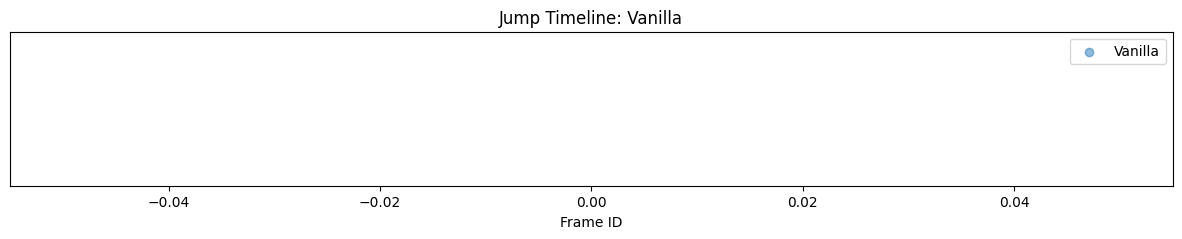

In [62]:
def plot_jump_timeline(jump_details, model_name):
    jumps = jump_details[jump_details['is_jump'] == True]
    plt.figure(figsize=(15, 2))
    plt.scatter(jumps['image_id'], [1]*len(jumps), alpha=0.5, label=model_name)
    plt.title(f"Jump Timeline: {model_name}")
    plt.xlabel("Frame ID")
    plt.yticks([])
    plt.legend()
    plt.show()

plot_jump_timeline(vanilla_detail, "Vanilla")

In [59]:
# 1. 플레이어 ID 추가
gt_df = df_label.copy() # 원본 보존
gt_df['player_id'] = gt_df.index % 5

# 2. 플레이어별로 streak 추적 수행
# 이전에 정의한 track_streaks_iou_fixed 함수를 플레이어별로 적용
player_streak_dfs = []
for p_id in range(5):
    player_df = gt_df[gt_df['player_id'] == p_id].copy()
    # 주의: 여기서 함수는 해당 플레이어의 프레임들만 가지고 streak을 계산해야 합니다
    player_streak_df = track_streaks_iou_fixed(player_df)
    player_streak_dfs.append(player_streak_df)

# 하나로 합침
processed_gt_df = pd.concat(player_streak_dfs)

In [63]:
processed_gt_df

,id,image_id,category_id,bbox,area,segmentation,iscrowd,x,y,streak_id,dx,dy,iou_score,angle,player_id
0,1,0,1,"[108, 2, 20, 12]",240,"[[108, 2, 128, 2, 128, 14, 108, 14]]",0,108,2,0,NaN,NaN,NaN,NaN,0
5,6,1,1,"[108, 2, 20, 12]",240,"[[108, 2, 128, 2, 128, 14, 108, 14]]",0,108,2,0,0.0,0.0,1.0,0.0,0
10,11,2,1,"[108, 2, 20, 12]",240,"[[108, 2, 128, 2, 128, 14, 108, 14]]",0,108,2,0,0.0,0.0,1.0,0.0,0
15,16,3,1,"[108, 2, 20, 12]",240,"[[108, 2, 128, 2, 128, 14, 108, 14]]",0,108,2,0,0.0,0.0,1.0,0.0,0
20,21,4,1,"[108, 2, 20, 12]",240,"[[108, 2, 128, 2, 128, 14, 108, 14]]",0,108,2,0,0.0,0.0,1.0,0.0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
90919,90920,18183,1,"[90, 83, 20, 12]",240,"[[90, 83, 110, 83, 110, 95, 90, 95]]",0,90,83,285,0.0,0.0,1.0,0.0,4
90924,90925,18184,1,"[90, 83, 20, 12]",240,"[[90, 83, 110, 83, 110, 95, 90, 95]]",0,90,83,285,0.0,0.0,1.0,0.0,4
90929,90930,18185,1,"[90, 83, 20, 12]",240,"[[90, 83, 110, 83, 110, 95, 90, 95]]",0,90,83,285,0.0,0.0,1.0,0.0,4
90934,90935,18186,1,"[90, 83, 20, 12]",240,"[[90, 83, 110, 83, 110, 95, 90, 95]]",0,90,83,285,0.0,0.0,1.0,0.0,4


--- 플레이어별 Streak Length 통계 ---
                 mean  median         std   max  count
player_id                                             
0          158.156522    99.0  174.033904  1090    115
1           99.934066    80.0   79.155809   407    182
2          112.968944    77.0  129.081487  1003    161
3           80.835556    61.0   63.623366   428    225
4           63.594406    17.5  108.658760   778    286


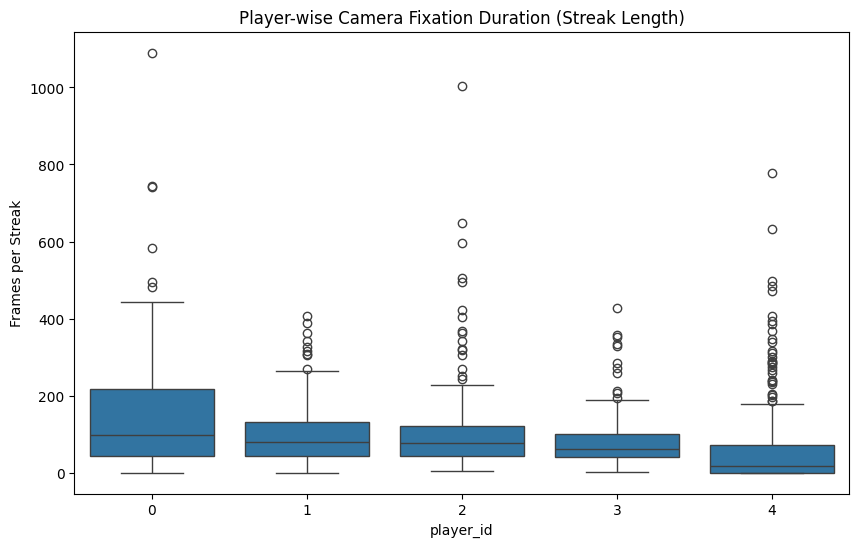

In [65]:
# 1. 각 streak_id 별로 길이 계산 (프레임 개수)
# streak_id가 플레이어 간에 겹칠 수 있으므로 player_id와 streak_id를 조합하여 고유 ID 생성
processed_gt_df['unique_streak_id'] = (
    processed_gt_df['player_id'].astype(str) + '_' + processed_gt_df['streak_id'].astype(str)
)

streak_lengths = processed_gt_df.groupby(['player_id', 'unique_streak_id']).size().reset_index(name='length')

# 2. 플레이어별 통계 산출
streak_stats = streak_lengths.groupby('player_id')['length'].agg(['mean', 'median', 'std', 'max', 'count'])
print("--- 플레이어별 Streak Length 통계 ---")
print(streak_stats)

# 3. 분포 시각화 (Boxplot)
import seaborn as sns
plt.figure(figsize=(10, 6))
sns.boxplot(x='player_id', y='length', data=streak_lengths)
plt.title("Player-wise Camera Fixation Duration (Streak Length)")
plt.ylabel("Frames per Streak")
plt.show()

In [70]:
def get_streak_stats(df, name):
    # 각 streak_id별 길이 계산
    stats = df.groupby('streak_id').size().reset_index(name='length')
    stats['model'] = name
    return stats

# 각 모델별 길이 통계 추출
stats_gt = get_streak_stats(processed_gt_df, 'GT')
stats_vanilla = get_streak_stats(track_streaks_iou_fixed(df_vanilla.copy()), 'Vanilla')
stats_kbrs = get_streak_stats(track_streaks_iou_fixed(df_kbrs.copy()), 'KBRS')

# 하나로 합치기
all_stats = pd.concat([stats_gt, stats_vanilla, stats_kbrs])

In [72]:
from scipy.stats import ks_2samp

# GT vs Vanilla, GT vs KBRS 비교
ks_v = ks_2samp(stats_gt['length'], stats_vanilla['length'])
ks_k = ks_2samp(stats_gt['length'], stats_kbrs['length'])

print(f"GT vs Vanilla 분포 유사도 (p-value): {ks_v.pvalue:.4f}")
print(f"GT vs KBRS 분포 유사도 (p-value): {ks_k.pvalue:.4f}")
# p-value가 높을수록 플레이어와 유사한 호흡을 가지고 있다는 의미입니다.

GT vs Vanilla 분포 유사도 (p-value): 0.0000
GT vs KBRS 분포 유사도 (p-value): 0.0000


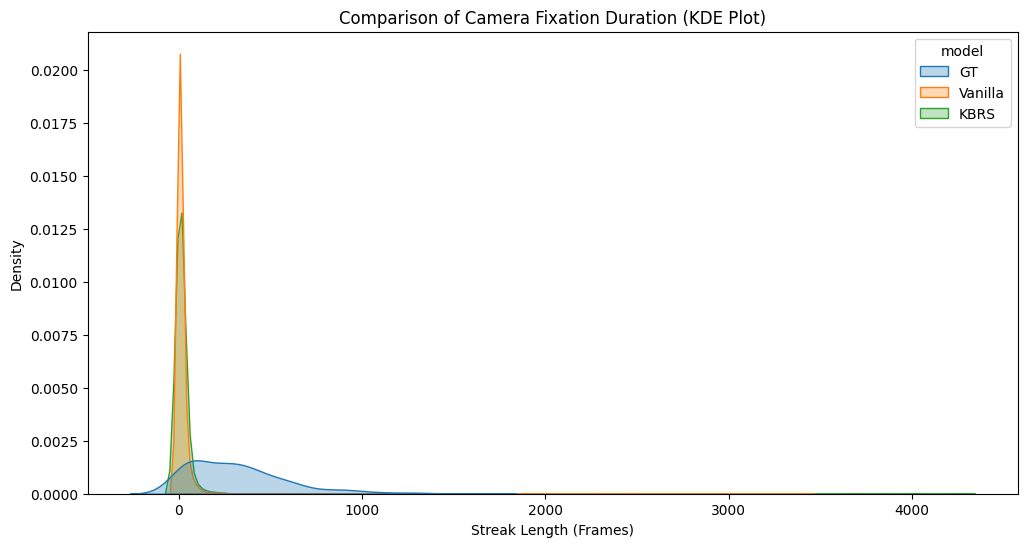

In [73]:
import seaborn as sns

plt.figure(figsize=(12, 6))
sns.kdeplot(data=all_stats, x='length', hue='model', fill=True, common_norm=False, alpha=0.3)
plt.title("Comparison of Camera Fixation Duration (KDE Plot)")
plt.xlabel("Streak Length (Frames)")
plt.show()

In [74]:
# 1. 모델의 프레임 간 거리 분포
def get_frame_to_frame_dist(df):
    df = df.sort_values(['image_id'])
    df['dx'] = df.groupby('streak_id')['x'].diff() # 혹은 단순 image_id 기준 diff
    df['dy'] = df.groupby('streak_id')['y'].diff()
    return np.sqrt(df['dx']**2 + df['dy']**2).dropna()

# 2. GT의 Streak 내 거리 분포와 비교
# GT는 플레이어별 streak 내에서의 이동 거리
# 모델은 프레임 간 이동 거리
# 이 두 분포의 차이가 작을수록 모델이 플레이어의 이동 속도(카메라 점프 성향)를 잘 모사함

In [75]:
def get_movement_distributions(vanilla_df, kbrs_df, gt_df):
    def compute_dists(df):
        # image_id 순서대로 정렬 후 프레임 간 거리 계산
        df = df.sort_values(['image_id'])
        # 좌표 계산 (x, y)
        df['x'] = df['bbox'].apply(lambda b: ast.literal_eval(b)[0] + 10 if isinstance(b, str) else b[0] + 10)
        df['y'] = df['bbox'].apply(lambda b: ast.literal_eval(b)[1] + 6 if isinstance(b, str) else b[1] + 6)
        
        # 이전 프레임과의 거리 계산
        df['dx'] = df['x'].diff()
        df['dy'] = df['y'].diff()
        dists = np.sqrt(df['dx']**2 + df['dy']**2).dropna()
        return dists

    # 각 데이터프레임별 이동 거리 추출
    vanilla_dists = compute_dists(vanilla_df)
    kbrs_dists = compute_dists(kbrs_df)
    gt_dists = compute_dists(gt_df)
    
    return vanilla_dists, kbrs_dists, gt_dists

# 거리 데이터 추출
v_d, k_d, g_d = get_movement_distributions(df_vanilla, df_kbrs, df_label)

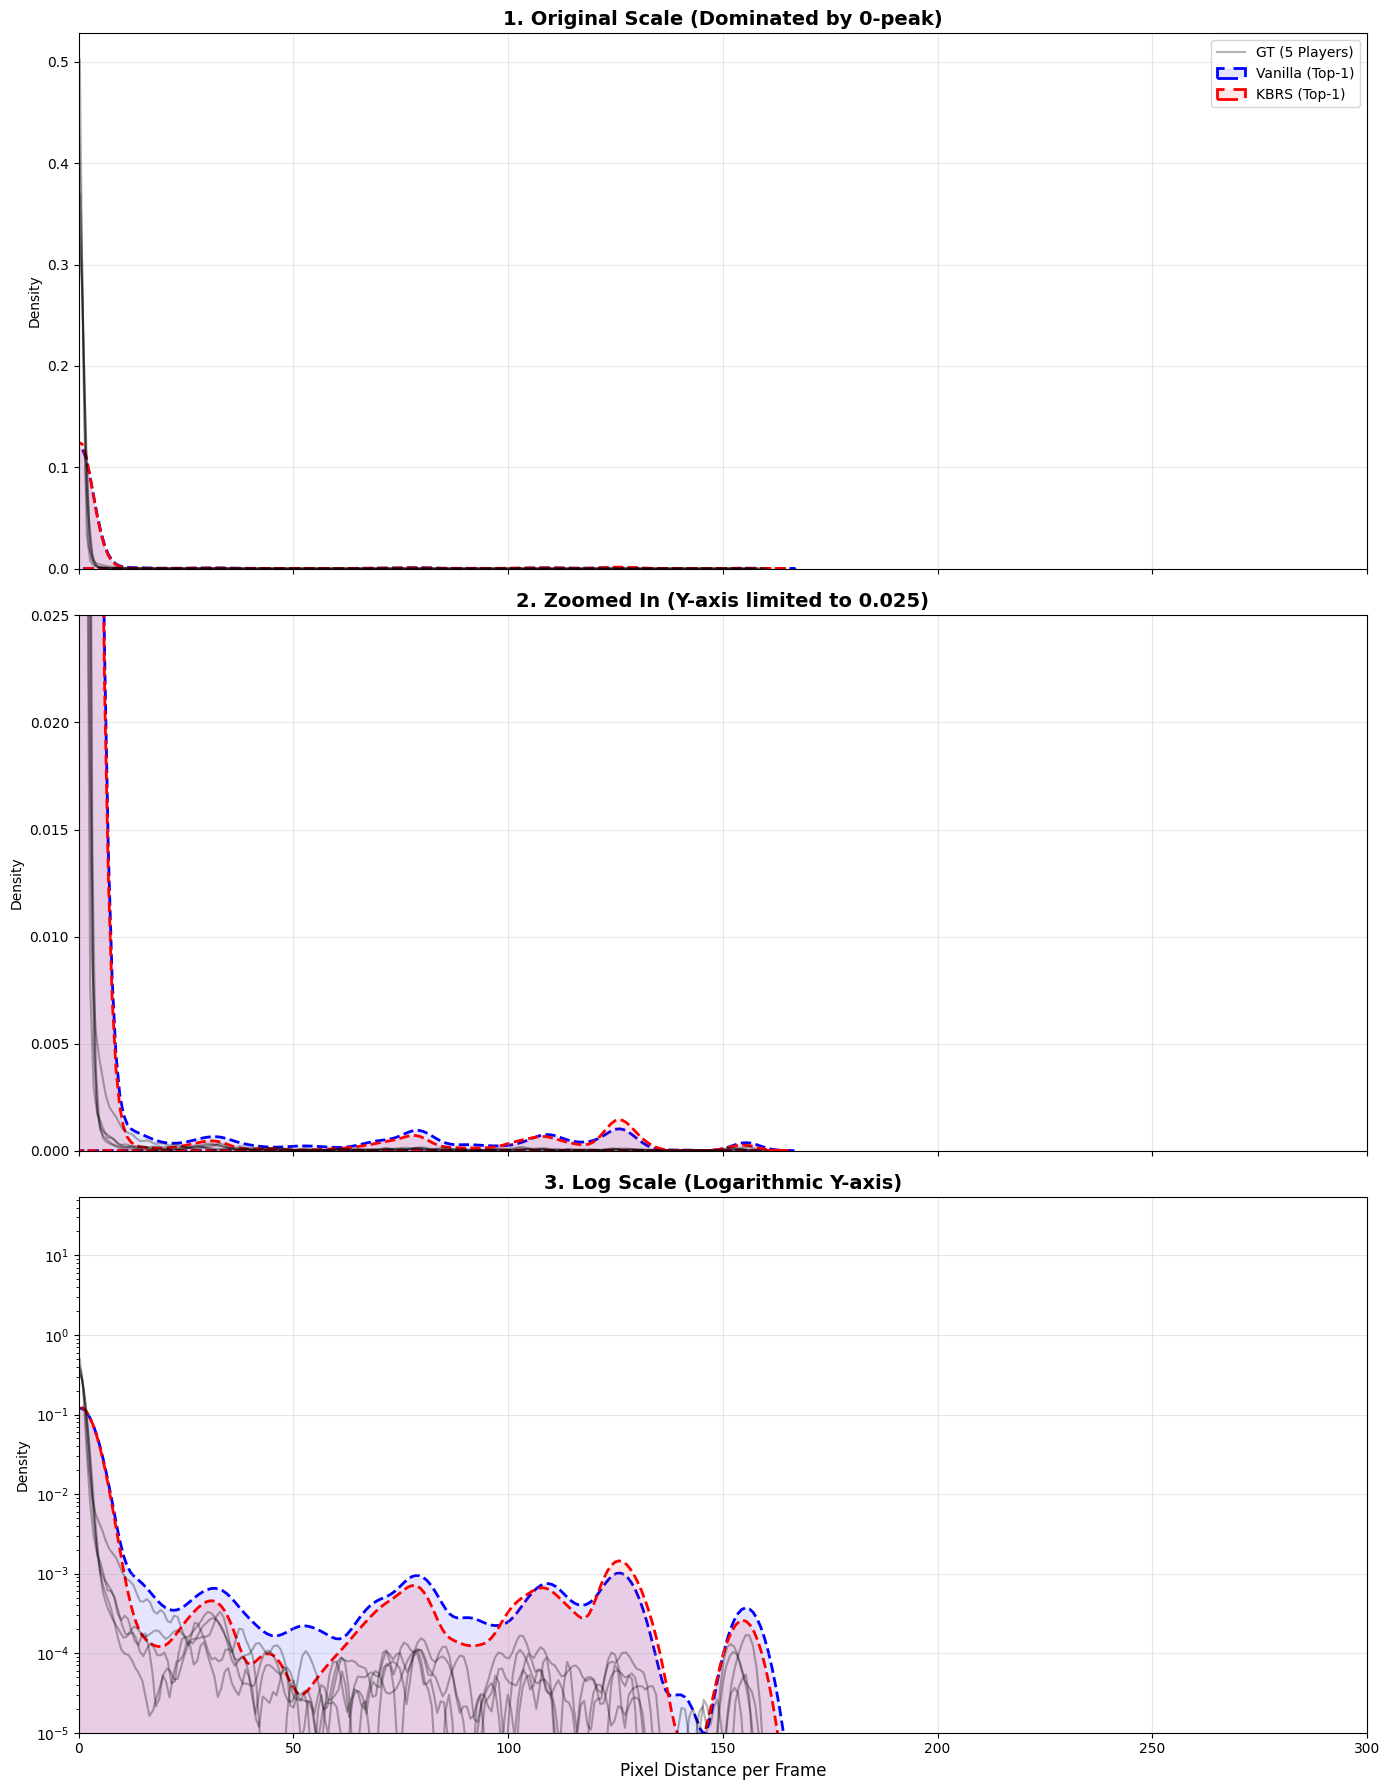

In [85]:
import matplotlib.pyplot as plt
import seaborn as sns

# 3행 1열의 Subplot 생성 (세로로 길게 배치)
fig, axes = plt.subplots(nrows=3, ncols=1, figsize=(14, 18), sharex=True)

# 공통으로 그래프를 그리는 헬퍼 함수
def draw_kde_on_ax(ax, title):
    # 1. GT 플레이어 5명의 궤적
    for p_id, dists in gt_dists_list:
        label = 'GT (5 Players)' if p_id == 0 else "_nolegend_"
        sns.kdeplot(dists, color='black', alpha=0.3, linewidth=1.5, ax=ax, label=label)
    
    # 2. 모델들 (Top-1)
    sns.kdeplot(v_d, color='blue', linestyle='--', linewidth=2, ax=ax, fill=True, alpha=0.1, label='Vanilla (Top-1)')
    sns.kdeplot(k_d, color='red', linestyle='--', linewidth=2, ax=ax, fill=True, alpha=0.1, label='KBRS (Top-1)')
    
    ax.set_title(title, fontsize=14, fontweight='bold')
    ax.set_ylabel("Density")
    ax.set_xlim(0, 300)
    ax.grid(True, alpha=0.3)
    
    # 첫 번째 그래프에만 범례 표시
    if ax == axes[0]: 
        ax.legend(loc='upper right')

# ==========================================
# 1. 원본 그림 (Original)
# ==========================================
draw_kde_on_ax(axes[0], "1. Original Scale (Dominated by 0-peak)")
# Y축 제한 없음 (0 부근의 거대한 피크 때문에 나머지가 납작해 보임)

# ==========================================
# 2. 돋보기 그림 (Zoomed-in)
# ==========================================
draw_kde_on_ax(axes[1], "2. Zoomed In (Y-axis limited to 0.025)")
# 💡 Y축을 강제로 0.025까지만 보여주어 낙타 등 패턴을 확대
axes[1].set_ylim(0, 0.025)

# ==========================================
# 3. 로그 스케일 그림 (Log Scale)
# ==========================================
draw_kde_on_ax(axes[2], "3. Log Scale (Logarithmic Y-axis)")
# 💡 Y축을 로그 스케일로 변환하여 전체적인 분포 비율을 왜곡 없이 확인
axes[2].set_yscale('log')
axes[2].set_ylim(bottom=1e-5) # 로그 스케일에서 무한대로 떨어지는 것 방지

# X축 라벨은 맨 아래 그래프에만 표시
axes[2].set_xlabel("Pixel Distance per Frame", fontsize=12)

# 그래프 간격 자동 조정
plt.tight_layout()
plt.show()

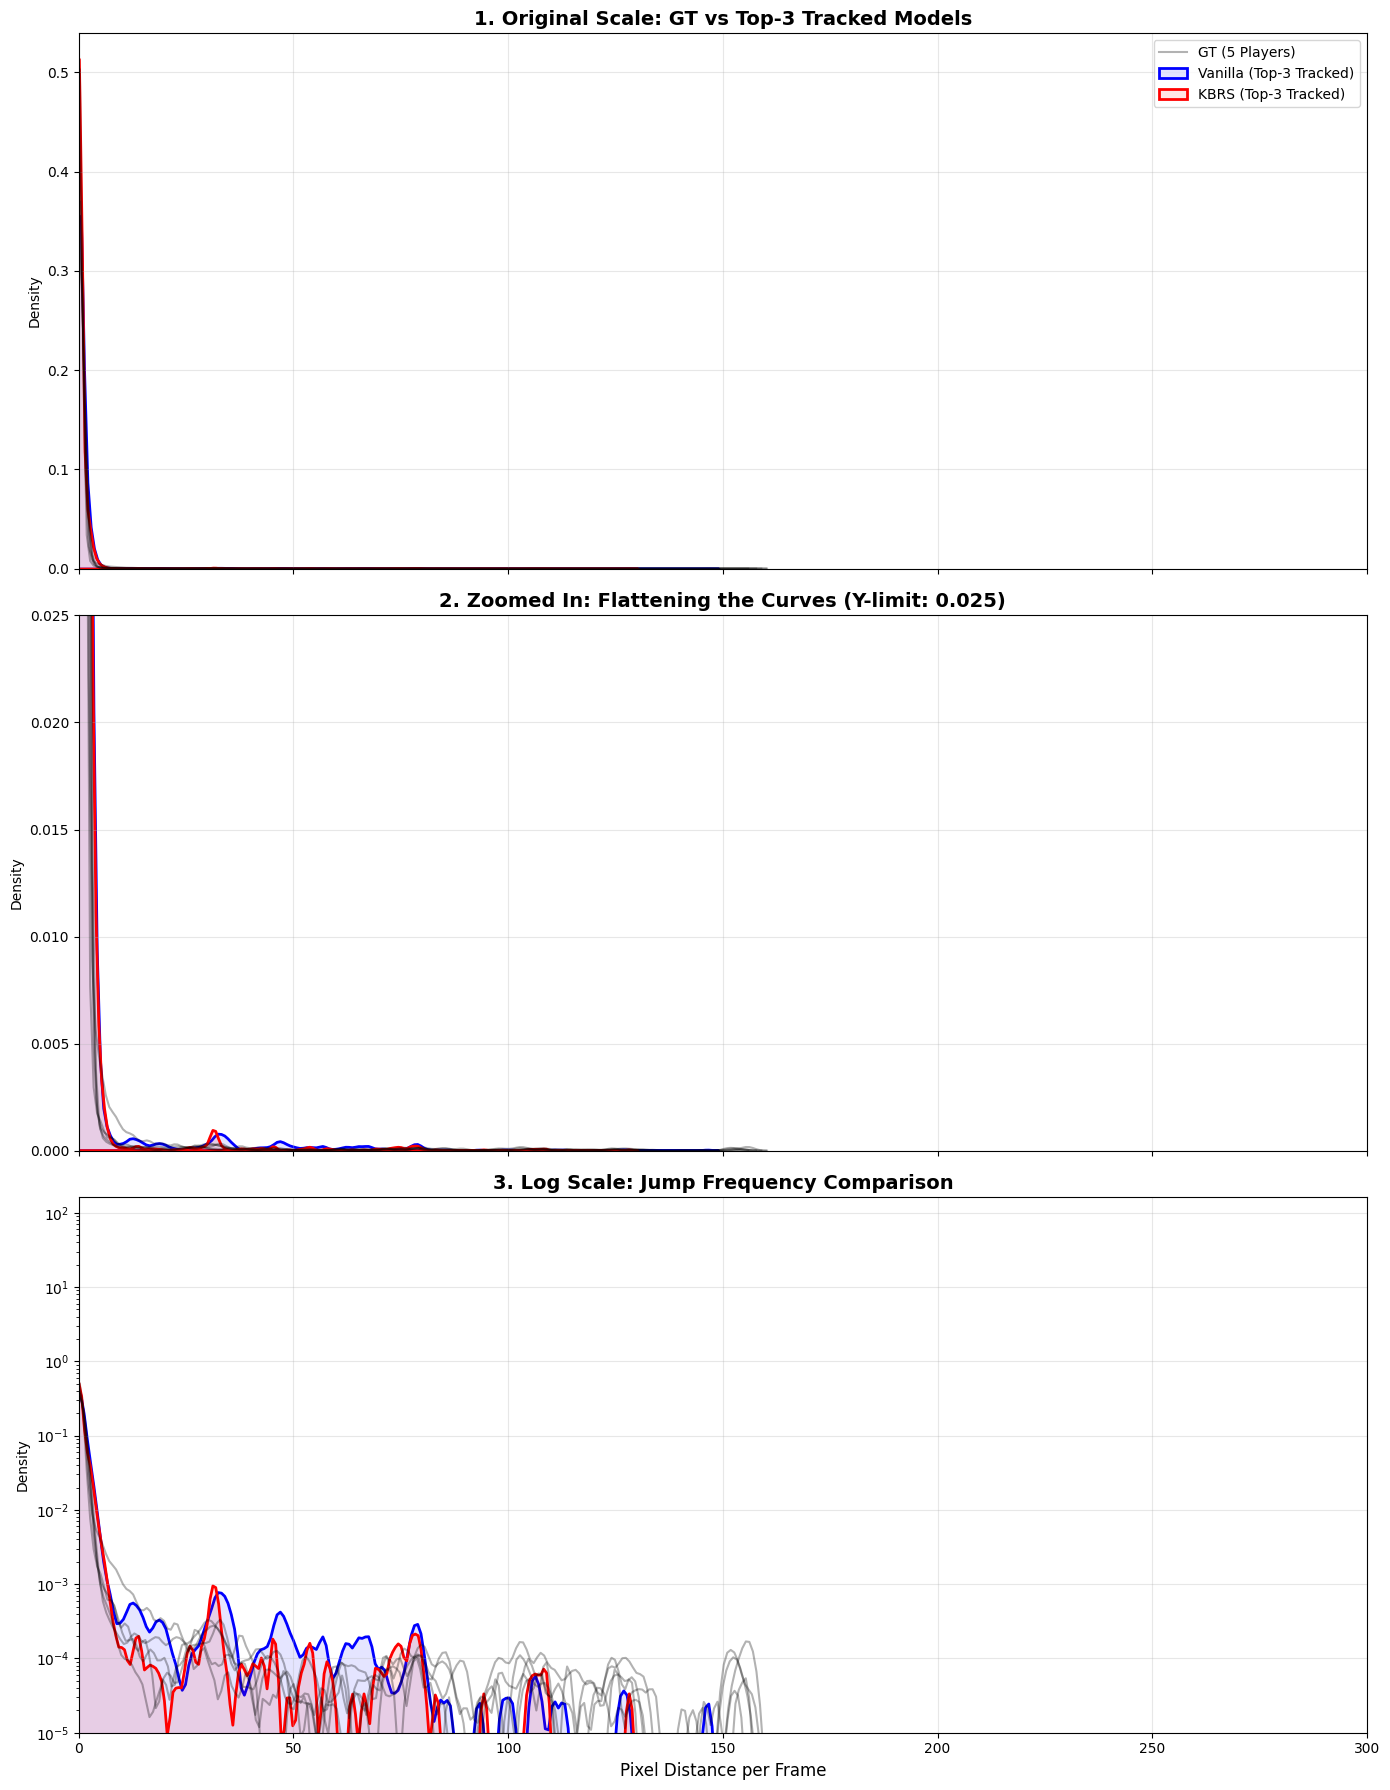

In [87]:
import matplotlib.pyplot as plt
import seaborn as sns

# 3행 1열의 Subplot 생성
fig, axes = plt.subplots(nrows=3, ncols=1, figsize=(14, 18), sharex=True)

# 💡 통합 시각화 헬퍼 함수 (Top-3 Tracked 데이터 사용)
def draw_tracked_kde_on_ax(ax, title):
    # 1. GT 플레이어 5명의 궤적
    for p_id, dists in gt_dists_list:
        label = 'GT (5 Players)' if p_id == 0 else "_nolegend_"
        sns.kdeplot(dists, color='black', alpha=0.3, linewidth=1.5, ax=ax, label=label)
    
    # 2. 모델들 (Top-3 Tracked 데이터로 변경됨!)
    # 비교하기 쉽게 선 스타일을 실선(-)으로 바꾸고 색을 유지합니다.
    sns.kdeplot(v_d_tracked, color='blue', linestyle='-', linewidth=2, ax=ax, fill=True, alpha=0.1, label='Vanilla (Top-3 Tracked)')
    sns.kdeplot(k_d_tracked, color='red', linestyle='-', linewidth=2, ax=ax, fill=True, alpha=0.1, label='KBRS (Top-3 Tracked)')
    
    ax.set_title(title, fontsize=14, fontweight='bold')
    ax.set_ylabel("Density")
    ax.set_xlim(0, 300)
    ax.grid(True, alpha=0.3)
    
    # 첫 번째 그래프에만 범례 표시
    if ax == axes[0]: 
        ax.legend(loc='upper right')

# ==========================================
# 1. 원본 그림 (Original)
# ==========================================
draw_tracked_kde_on_ax(axes[0], "1. Original Scale: GT vs Top-3 Tracked Models")

# ==========================================
# 2. 돋보기 그림 (Zoomed-in)
# ==========================================
draw_tracked_kde_on_ax(axes[1], "2. Zoomed In: Flattening the Curves (Y-limit: 0.025)")
axes[1].set_ylim(0, 0.025)

# ==========================================
# 3. 로그 스케일 그림 (Log Scale)
# ==========================================
draw_tracked_kde_on_ax(axes[2], "3. Log Scale: Jump Frequency Comparison")
axes[2].set_yscale('log')
axes[2].set_ylim(bottom=1e-5) 

# X축 라벨
axes[2].set_xlabel("Pixel Distance per Frame", fontsize=12)

plt.tight_layout()
plt.show()

In [89]:
import os
import ast
import numpy as np
import pandas as pd

# ==========================================
# 1. 궤적 생성 헬퍼 함수
# ==========================================
def add_center(df):
    """Bbox에서 중심점(Center) 좌표를 계산하여 컬럼 추가"""
    df_copy = df.copy()
    def get_center(b):
        bbox = ast.literal_eval(b) if isinstance(b, str) else b
        return np.array([bbox[0] + 10, bbox[1] + 6])
    df_copy['center'] = df_copy['bbox'].apply(get_center)
    return df_copy

def get_top1_greedy(df):
    """Top-1 프레임만 추출 (순정 모델)"""
    df_copy = add_center(df)
    if 'rank' not in df_copy.columns:
        df_copy['rank'] = df_copy.groupby('image_id')['score'].rank(ascending=False, method='first').astype(int)
    return df_copy[df_copy['rank'] == 1].copy()

def get_top_k_tracked(df, k=3):
    """Top-K 내에서 이전 프레임 위치(관성)를 고려한 궤적 생성"""
    df_copy = add_center(df)
    if 'rank' not in df_copy.columns:
        df_copy['rank'] = df_copy.groupby('image_id')['score'].rank(ascending=False, method='first').astype(int)
        
    df_topk = df_copy[df_copy['rank'] <= k].sort_values(['image_id', 'rank'])
    image_ids = sorted(df_topk['image_id'].unique())
    if not image_ids: return pd.DataFrame()
    
    chosen_rows = []
    best_first = df_topk[df_topk['image_id'] == image_ids[0]].iloc[0]
    chosen_rows.append(best_first)
    current_anchor = best_first['center']
    
    for img_id in image_ids[1:]:
        candidates = df_topk[df_topk['image_id'] == img_id]
        if candidates.empty: continue
            
        best_candidate = None
        min_dist = float('inf')
        for _, row in candidates.iterrows():
            dist = np.linalg.norm(row['center'] - current_anchor)
            if dist < min_dist:
                min_dist = dist
                best_candidate = row
                
        chosen_rows.append(best_candidate)
        current_anchor = best_candidate['center']
        
    return pd.DataFrame(chosen_rows)

# ==========================================
# 2. IoU 기반 시야 품질 평가 함수
# ==========================================
def evaluate_viewport_quality_iou(model_df, gt_df, kbrs_cache_files, iou_threshold=0.1):
    df = model_df.copy()
    df['gt_matched'] = False
    df['max_iou_with_gt'] = 0.0
    df['significance_score'] = np.nan
    
    # GT 데이터 전처리 (빠른 탐색을 위해 딕셔너리화)
    gt_df_copy = gt_df.copy()
    gt_df_copy['bbox_parsed'] = gt_df_copy['bbox'].apply(lambda b: ast.literal_eval(b) if isinstance(b, str) else b)
    
    gt_dict = {}
    for img_id, group in gt_df_copy.groupby('image_id'):
        gt_dict[img_id] = np.array([bbox[:2] for bbox in group['bbox_parsed']])

    for idx, row in df.iterrows():
        frame_id = row['image_id']
        m_box = ast.literal_eval(row['bbox']) if isinstance(row['bbox'], str) else row['bbox']
        model_coords = np.array([[m_box[0], m_box[1]]])
        
        # 1. IoU 계산 (calculate_fixed_iou_matrix 함수 필요)
        if frame_id in gt_dict:
            gt_coords = gt_dict[frame_id]
            if len(gt_coords) > 0:
                iou_matrix = calculate_fixed_iou_matrix(model_coords, gt_coords)
                max_iou = iou_matrix[0].max()
                df.at[idx, 'max_iou_with_gt'] = max_iou
                if max_iou >= iou_threshold:
                    df.at[idx, 'gt_matched'] = True
                
        # 2. KBRS Score 추출
        cache_file = next((f for f in kbrs_cache_files if os.path.basename(f) == f"{frame_id}.npz"), None)
        if cache_file and os.path.exists(cache_file):
            cache_data = np.load(cache_file)
            try:
                cx = int(np.clip(m_box[0] + 10, 0, cache_data['density'].shape[1] - 1))
                cy = int(np.clip(m_box[1] + 6, 0, cache_data['density'].shape[0] - 1))
                d = cache_data['density'][cy, cx]
                c = cache_data['centeredness'][cy, cx]
                m = cache_data['mixture'][cy, cx]
                df.at[idx, 'significance_score'] = d * c * m
            except: pass 
            
    return df

# ==========================================
# 3. 데이터 파이프라인 실행 및 결과 출력
# ==========================================
print("🚀 데이터 궤적 생성 및 평가 중... 잠시만 기다려주세요.\n")

# 데이터 생성
v_top1 = get_top1_greedy(df_vanilla)
v_top3 = get_top_k_tracked(df_vanilla, k=3)
k_top1 = get_top1_greedy(df_kbrs)
k_top3 = get_top_k_tracked(df_kbrs, k=3)

# 품질 평가
eval_v_t1 = evaluate_viewport_quality_iou(v_top1, df_label, kbrs_cache_files)
eval_v_t3 = evaluate_viewport_quality_iou(v_top3, df_label, kbrs_cache_files)
eval_k_t1 = evaluate_viewport_quality_iou(k_top1, df_label, kbrs_cache_files)
eval_k_t3 = evaluate_viewport_quality_iou(k_top3, df_label, kbrs_cache_files)

# 결과 요약 함수
def print_summary(name, df):
    hit_rate = df['gt_matched'].mean() * 100
    avg_score = df['significance_score'].mean()
    fatal_miss = len(df[(df['gt_matched'] == False) & (df['significance_score'] < 0.1)]) / len(df) * 100
    
    print(f"[{name}]")
    print(f" - GT Hit Rate (IoU >= 0.1) : {hit_rate:5.2f}%")
    print(f" - Average Sig. Score       : {avg_score:5.4f}")
    print(f" - Fatal Miss Rate          : {fatal_miss:5.2f}%\n")

# 최종 결과 출력
print("=========================================")
print("      📊 Viewport Quality Analysis       ")
print("=========================================\n")
print_summary("1. Vanilla (Top-1 Greedy)", eval_v_t1)
print_summary("2. Vanilla (Top-3 Tracked)", eval_v_t3)
print_summary("3. KBRS (Top-1 Greedy)", eval_k_t1)
print_summary("4. KBRS (Top-3 Tracked)", eval_k_t3)

🚀 데이터 궤적 생성 및 평가 중... 잠시만 기다려주세요.

      📊 Viewport Quality Analysis       

[1. Vanilla (Top-1 Greedy)]
 - GT Hit Rate (IoU >= 0.1) : 82.39%
 - Average Sig. Score       : 0.0576
 - Fatal Miss Rate          : 17.06%

[2. Vanilla (Top-3 Tracked)]
 - GT Hit Rate (IoU >= 0.1) : 80.98%
 - Average Sig. Score       : 0.0647
 - Fatal Miss Rate          : 18.10%

[3. KBRS (Top-1 Greedy)]
 - GT Hit Rate (IoU >= 0.1) : 83.48%
 - Average Sig. Score       : 0.0615
 - Fatal Miss Rate          : 15.91%

[4. KBRS (Top-3 Tracked)]
 - GT Hit Rate (IoU >= 0.1) : 80.52%
 - Average Sig. Score       : 0.0714
 - Fatal Miss Rate          : 18.52%



In [91]:
# ==========================================
# 결과 요약 함수 (세부 커널 지표 분리 버전)
# ==========================================
def print_summary(name, df):
    # GT 매칭률 및 치명적 오류율
    hit_rate = df['gt_matched'].mean() * 100
    fatal_miss = len(df[(df['gt_matched'] == False) & (df['significance_score'] < 0.1)]) / len(df) * 100
    
    # 통합 스코어 및 세부 커널 스코어 평균 계산
    avg_score = df['significance_score'].mean()
    avg_density = df['density'].mean()
    avg_centeredness = df['centeredness'].mean()
    avg_mixture = df['mixture'].mean()
    
    print(f"[{name}]")
    print(f" - GT Hit Rate (IoU >= 0.1) : {hit_rate:5.2f}%")
    print(f" - Fatal Miss Rate          : {fatal_miss:5.2f}%")
    print(f" ---------------------------------------")
    print(f" - Avg Total Score          : {avg_score:5.4f}")
    print(f"   > Avg Density (Mass)     : {avg_density:5.4f})
    print(f"   > Avg Centered (Framing) : {avg_centeredness:5.4f}")
    print(f"   > Avg Mixture (Action)   : {avg_mixture:5.4f}")
    print(f"=========================================\n")

# 최종 결과 출력 (이전과 동일하게 호출)
print("=========================================")
print("      📊 Viewport Quality Analysis       ")
print("=========================================\n")
print_summary("1. Vanilla (Top-1 Greedy)", eval_v_t1)
print_summary("2. Vanilla (Top-3 Tracked)", eval_v_t3)
print_summary("3. KBRS (Top-1 Greedy)", eval_k_t1)
print_summary("4. KBRS (Top-3 Tracked)", eval_k_t3)

SyntaxError: unterminated f-string literal (detected at line 20) (3748517468.py, line 20)

In [92]:
eval_v_t1

,id,image_id,category_id,bbox,score,area,segmentation,iscrowd,x,y,streak_id,dx,dy,iou_score,angle,center,rank,gt_matched,max_iou_with_gt,significance_score
0,1,3,1,"[0, 0, 19, 12]",0.796460,228,"[[0, 0, 19, 0, 19, 12, 0, 12]]",0,0,0,0,NaN,NaN,NaN,NaN,"[10, 6]",1,False,0.000000,0.0
2,3,4,1,"[0, 0, 19, 12]",0.796460,228,"[[0, 0, 19, 0, 19, 12, 0, 12]]",0,0,0,0,0.0,0.0,1.0,0.0,"[10, 6]",1,False,0.000000,0.0
4,5,5,1,"[0, 0, 19, 12]",0.796460,228,"[[0, 0, 19, 0, 19, 12, 0, 12]]",0,0,0,0,0.0,0.0,1.0,0.0,"[10, 6]",1,False,0.000000,0.0
6,7,6,1,"[0, 0, 19, 12]",0.796460,228,"[[0, 0, 19, 0, 19, 12, 0, 12]]",0,0,0,0,0.0,0.0,1.0,0.0,"[10, 6]",1,False,0.000000,0.0
8,9,7,1,"[0, 0, 19, 12]",0.796460,228,"[[0, 0, 19, 0, 19, 12, 0, 12]]",0,0,0,0,0.0,0.0,1.0,0.0,"[10, 6]",1,False,0.000000,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
108797,108798,18183,1,"[97, 85, 20, 12]",0.999164,240,"[[97, 85, 117, 85, 117, 97, 97, 97]]",0,97,85,14263,0.0,0.0,1.0,0.0,"[107, 91]",1,True,0.655172,0.0
108803,108804,18184,1,"[97, 85, 20, 12]",0.999236,240,"[[97, 85, 117, 85, 117, 97, 97, 97]]",0,97,85,14263,0.0,0.0,1.0,0.0,"[107, 91]",1,True,0.655172,0.0
108808,108809,18185,1,"[97, 85, 20, 12]",0.999246,240,"[[97, 85, 117, 85, 117, 97, 97, 97]]",0,97,85,14263,0.0,0.0,1.0,0.0,"[107, 91]",1,True,0.655172,0.0
108813,108814,18186,1,"[97, 85, 20, 12]",0.999321,240,"[[97, 85, 117, 85, 117, 97, 97, 97]]",0,97,85,14263,0.0,0.0,1.0,0.0,"[107, 91]",1,True,0.655172,0.0
